# 神经网络的基本结构
在人工智能的浪潮中，深度学习无疑是其中最耀眼的明星，而构成深度学习核心的，正是神经网络。它模仿人脑神经元的工作方式，通过层层连接与计算，赋予了机器学习和认知的能力。

对于初学者而言，理解神经网络的基本结构，是打开深度学习大门的第一把钥匙。

本文将带你从零开始，一步步拆解神经网络的构成，并用生动的比喻和清晰的代码，让你彻底掌握其工作原理。

----

## 神经网络是什么?
想象一下，你正在教一个从未见过猫和狗的小朋友区分它们，你会怎么做？

- 你可能会先给他看很多猫和狗的图片。
- 你会指出特征：看，猫的耳朵通常是尖的，脸比较圆；狗的耳朵可能下垂，脸型更长。
- 小朋友的大脑（神经网络）会接收这些图片（输入数据）和你的指导（标签）。
- 他大脑中的神经元会开始工作，尝试找出区分猫和狗的关键模式（如耳朵形状、脸型）。
- 经过多次纠正和学习，他大脑中形成了一个判断模型。下次再看到新动物图片时，他就能自信地说出这是猫或这是狗。

神经网络就是这个小朋友的大脑的简化数学模型， 它是一个由大量人工神经元相互连接构成的网络系统，能够从输入数据中自动学习特征和模式，并用于预测或决策。

-----

### 神经网络的基本组成单元：神经元
神经元是神经网络最基本的计算单元，它模拟了生物神经元接收信号-处理信号-传递信号的过程。

### 一个神经元的工作流程
一个典型的人工神经元主要做三件事：

In [1]:
# 这是一个神经元计算的伪代码逻辑，帮助你理解过程
def artificial_neuron(inputs, weights, bias):
    """
    模拟一个人工神经元的计算过程。
    参数:
        inputs: 输入信号列表，例如 [x1, x2, x3]
        weights: 对应每个输入的权重列表，例如 [w1, w2, w3]
        bias: 偏置项，一个常数
    返回:
        output: 神经元的输出
    """
    # 1. 加权求和：将每个输入乘以其对应的权重，然后加上偏置
    weighted_sum = 0
    for i in range(len(inputs)):
        weighted_sum += inputs[i] * weights[i]
    weighted_sum += bias

    # 2. 激活函数处理：通过一个非线性函数，决定是否"激活"并输出信号
    output = activation_function(weighted_sum)

    return output

让我们用一张图和一个表格来详细解释这个流程：
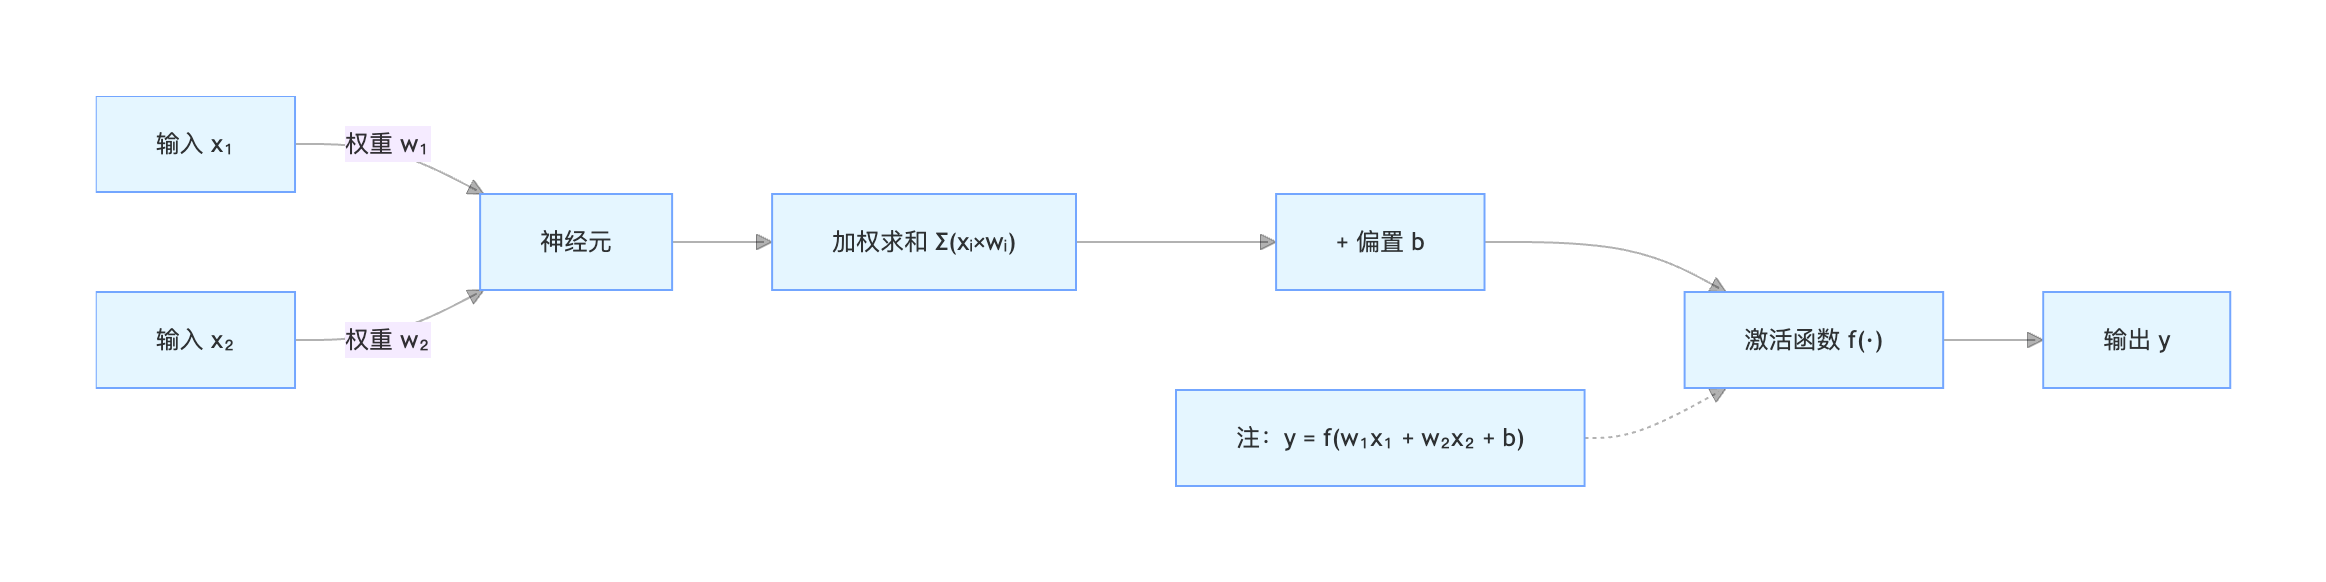

神经元各个部分的功能如下：
|部件|类比|数学表达|作用|
|---|---|---|---|
|输入（Input）|感觉器官|x1, x2, ..., xn|接收外界信息|
|权重（Weights）|神经连接的强度|w1, w2, ..., wn|调整输入的重要性|
|加权和（Weighted Sum）|大脑处理信息的方式|z = w1*x1 + w2*x2 + ... + wn*xn|整合输入信息|
|激活函数（Activation Function）|大脑的决策机制|a = f(z)|引入非线性，使网络能够学习复杂模式|
|输出（Output）|行为反应|a|传递处理结果到下一层或最终输出|

#### 常见的激活函数
- **Sigmoid 函数**：输出范围在 (0, 1)，适用于二分类问题。
    $$f(x) = \frac{1}{1 + e^{-x}}$$

- **ReLU 函数**：输出为输入的正部分，适用于深层网络，能够缓解梯度消失问题。
    $$f(x) = \max(0, x)$$
- **Tanh函数**：输出范围在 (-1, 1)，适用于需要中心化数据的情况。
    $$f(x) = \tanh(x)$$

- **Softmax函数**：用于多分类问题，将输出转换为概率分布。
    $$f(x_i) = \frac{e^{x_i}}{\sum_{j} e^{x_j}}$$

-----

### 神经的连接与层次结构
神经网络由多个神经元组成，这些神经元通过连接形成层次结构。常见的层次结构包括：
- **输入层（Input Layer）**：接收原始数据的层。
- **隐藏层（Hidden Layer）**：位于输入层和输出层之间，负责特征提取和模式识别。一个网络可以有一个或多个隐藏层。
- **输出层（Output Layer）**：产生最终预测结果的层。

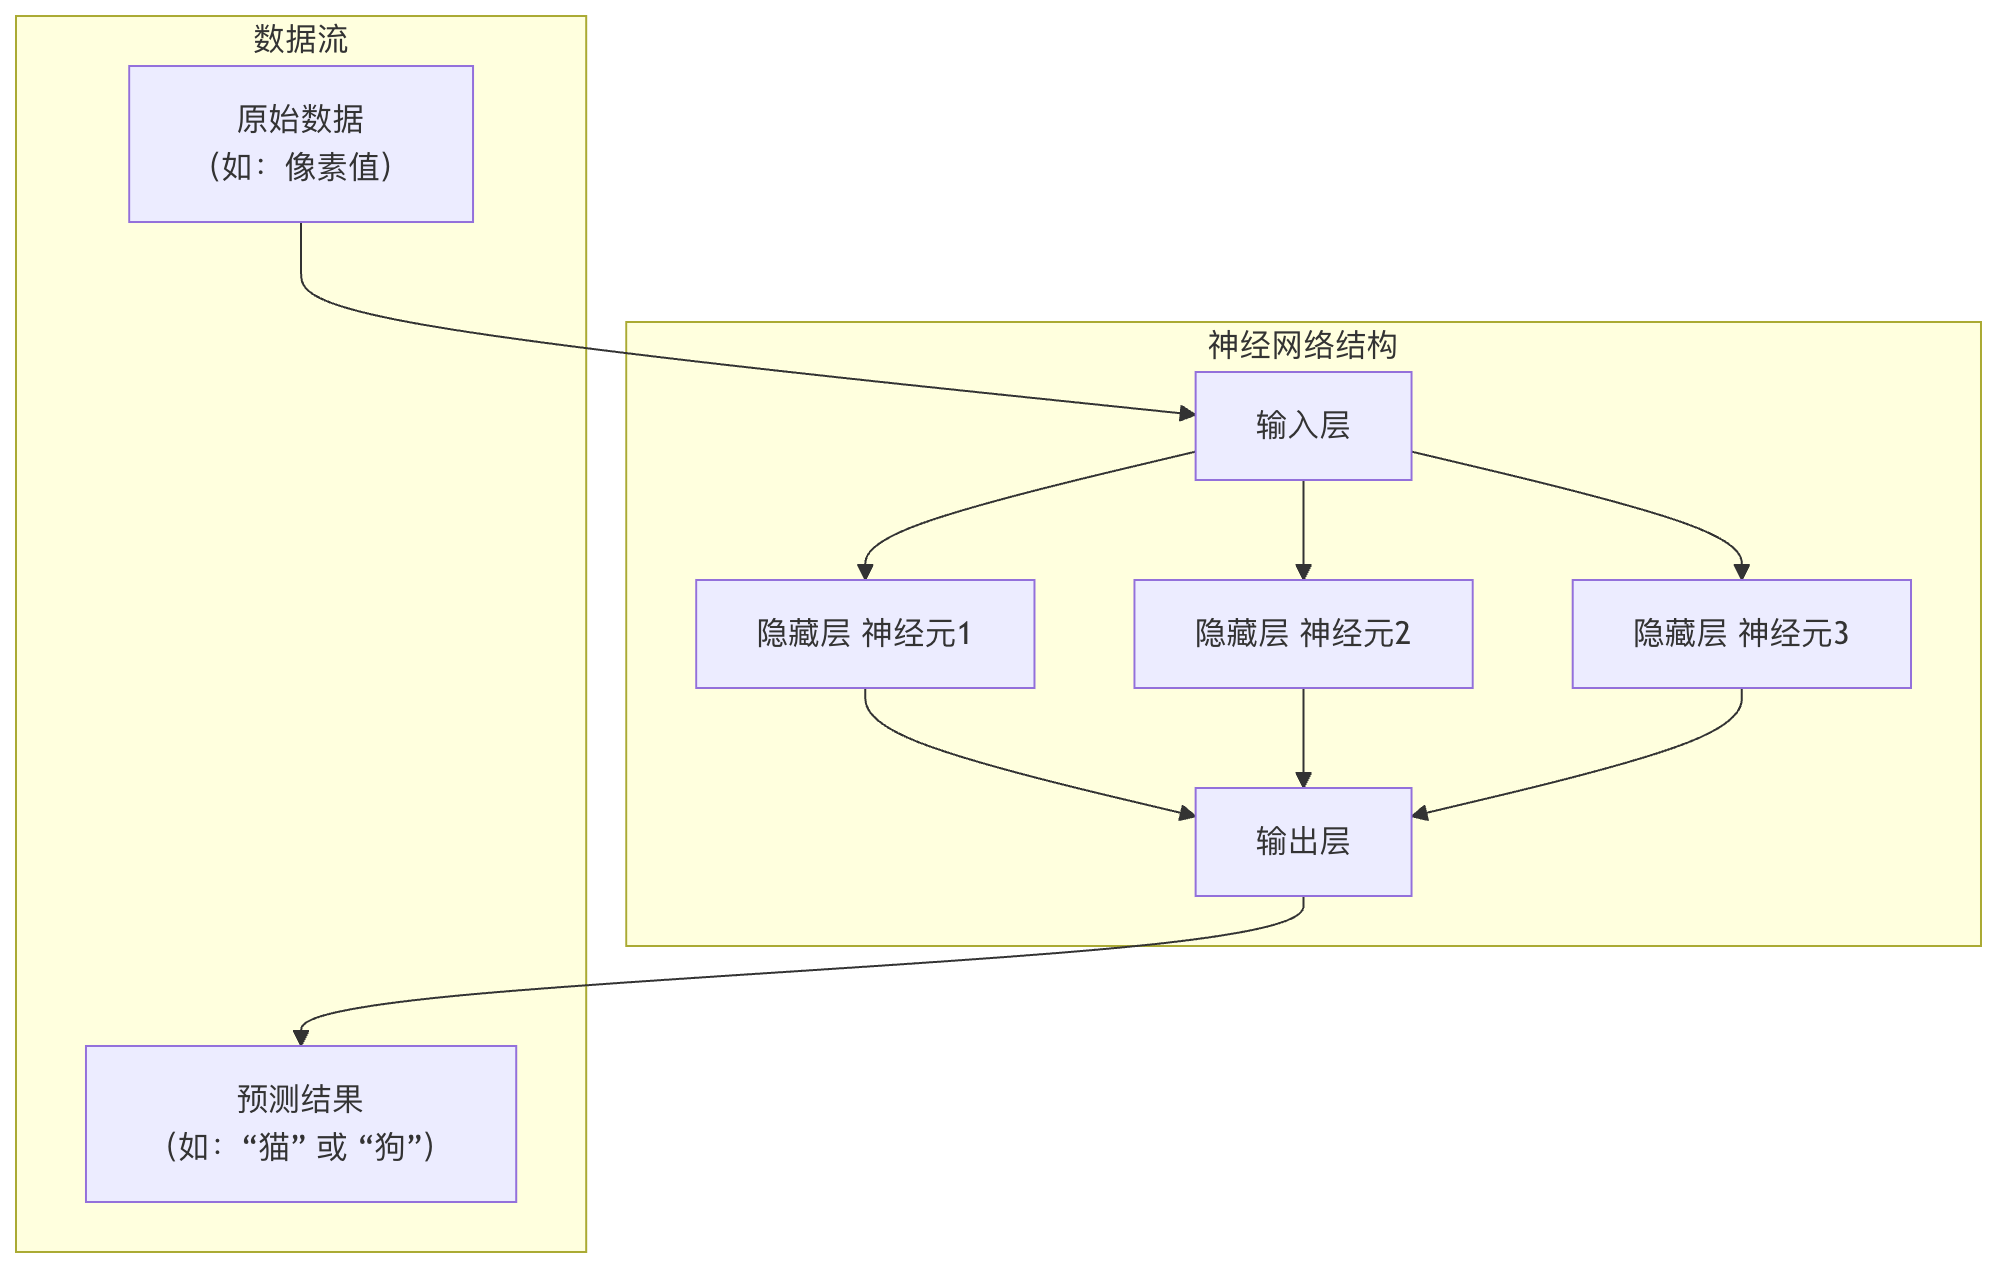

#### 1. 输入层
输入层的神经元数量通常与输入数据的特征数量相同。例如，如果你有一个包含 100 个特征的数据集，那么输入层就会有 100 个神经元。

#### 2. 隐藏层
隐藏层的神经元数量和层数是设计神经网络时需要调整的超参数。更多的隐藏层和神经元可以让网络学习更复杂的模式，但也可能导致过拟合。

#### 3. 输出层
输出层的神经元数量取决于具体任务。例如，在二分类问题中，输出层通常只有一个神经元（使用 Sigmoid 激活函数），而在多分类问题中，输出层的神经元数量等于类别数量（使用 Softmax 激活函数）。

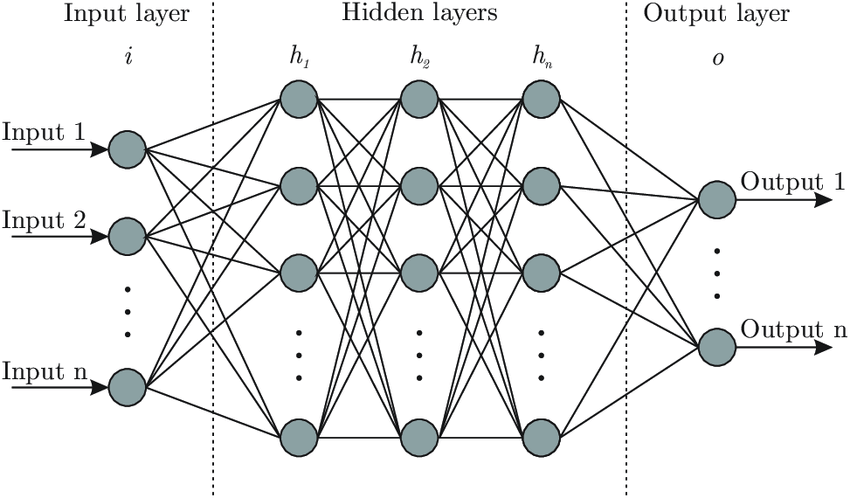

In [3]:
import numpy as np

# 定义激活函数
def sigmoid(x):
    """Sigmoid 激活函数"""
    return 1 / (1 + np.exp(-x))

def relu(x):
    """ReLU 激活函数"""
    return np.maximum(0, x)

# 初始化一个简单的神经网络
def initialize_network(input_size, hidden_size, output_size):
    """
    初始化网络权重和偏置。
    参数:
        input_size: 输入层神经元数
        hidden_size: 隐藏层神经元数
        output_size: 输出层神经元数
    返回:
        network: 包含各层参数的字典
    """
    np.random.seed(42)  # 设置随机种子，确保每次运行结果一致
    network = {}
    # 初始化 输入层->隐藏层 的参数
    # 权重矩阵形状: (下一层神经元数， 上一层神经元数)
    network['W1'] = np.random.randn(hidden_size, input_size) * 0.01
    network['b1'] = np.zeros((hidden_size, 1))  # 偏置是列向量
    # 初始化 隐藏层->输出层 的参数
    network['W2'] = np.random.randn(output_size, hidden_size) * 0.01
    network['b2'] = np.zeros((output_size, 1))
    return network

# 前向传播函数
def forward_propagation(network, X):
    """
    执行前向传播，计算网络输出。
    参数:
        network: 包含权重和偏置的字典
        X: 输入数据，形状为 (特征数, 样本数)
    返回:
        y_pred: 网络预测输出
        cache: 缓存中间结果（用于后续的反向传播）
    """
    # 获取参数
    W1, b1, W2, b2 = network['W1'], network['b1'], network['W2'], network['b2']

    # 第1层计算: 输入层 -> 隐藏层
    Z1 = np.dot(W1, X) + b1  # 加权和
    A1 = relu(Z1)            # 通过ReLU激活函数

    # 第2层计算: 隐藏层 -> 输出层
    Z2 = np.dot(W2, A1) + b2 # 加权和
    A2 = sigmoid(Z2)         # 通过Sigmoid激活函数（假设是二分类）

    # 缓存中间结果，反向传播时会用到
    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
    return A2, cache

# --- 让我们来运行它！---
# 1. 定义网络结构：2个输入特征，3个隐藏神经元，1个输出（二分类）
input_size = 2
hidden_size = 3
output_size = 1

# 2. 初始化网络
my_network = initialize_network(input_size, hidden_size, output_size)
print("权重 W1 的形状（隐藏层 x 输入层）:", my_network['W1'].shape)
print("偏置 b1 的形状:", my_network['b1'].shape)
print("权重 W2 的形状（输出层 x 隐藏层）:", my_network['W2'].shape)

# 3. 创建一个样本输入数据（2个特征，1个样本）
# X 的列代表样本，行代表特征
X_sample = np.array([[1.5], [-0.5]])  # 形状 (2, 1)
print("\n输入数据 X:", X_sample.T) # .T 是为了转置打印，便于观看

# 4. 执行前向传播
y_pred, cache = forward_propagation(my_network, X_sample)
print("\n神经网络预测输出 (A2):", y_pred)
# 如果输出 > 0.5，我们可以认为是类别1，否则是类别0
predicted_class = 1 if y_pred > 0.5 else 0
print(f"预测类别: {predicted_class}")

权重 W1 的形状（隐藏层 x 输入层）: (3, 2)
偏置 b1 的形状: (3, 1)
权重 W2 的形状（输出层 x 隐藏层）: (1, 3)

输入数据 X: [[ 1.5 -0.5]]

神经网络预测输出 (A2): [[0.50003617]]
预测类别: 1
